<a href="https://colab.research.google.com/github/rishiraj4/ML-Project/blob/main/ML_Project_Phase2_Rishi_Raj_N.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Electrical Grid Stability

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import datasets, svm, metrics
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectPercentile, f_classif
from sklearn.manifold import TSNE
from mpl_toolkits.mplot3d import Axes3D

In [ ]:
egs = pd.read_csv("/content/Data_for_UCI_named.csv")

In [ ]:
X = egs.iloc[:, :12].values
y = egs.iloc[:, 13].values

In [ ]:
le = LabelEncoder()

y= le.fit_transform(y)
print(y)

[1 0 1 ... 0 1 1]


**Splitting data into 75% training and 25% testing**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = 0.25,
                                                    stratify=y,
                                                    random_state=42)

Applying Standization Feature Scaling and checking the performance of the model

In [ ]:
sfc = StandardScaler()
sfc.fit(X_train)

X_train_std = sfc.transform(X_train)
X_test_std = sfc.transform(X_test)

**Hyperparameter tuning for SVM with RBF kernel**

In [ ]:
#RBF SVM model
KSVM_std = svm.SVC(kernel='rbf', random_state = 42)

In [ ]:
#F1 score
KSVM_std.fit(X_train_std, y_train)
y_pred = KSVM_std.predict(X_test_std)
F1_rbf = f1_score(y_test, y_pred)
F1_rbf

0.9670602858918583

In [ ]:
KSVM_std.get_params()

{'C': 1.0,
 'break_ties': False,
 'cache_size': 200,
 'class_weight': None,
 'coef0': 0.0,
 'decision_function_shape': 'ovr',
 'degree': 3,
 'gamma': 'scale',
 'kernel': 'rbf',
 'max_iter': -1,
 'probability': False,
 'random_state': 42,
 'shrinking': True,
 'tol': 0.001,
 'verbose': False}

In [ ]:
KSVM_param_grid = [
    {'C':[i for i in range(1,10)],
     'gamma': np.linspace(0.1, 1, 10)}
     ]

In [ ]:
KSVM_param_grid

[{'C': [1, 2, 3, 4, 5, 6, 7, 8, 9],
  'gamma': array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ])}]

In [ ]:
gs_rbf = GridSearchCV(estimator = KSVM_std,
                           param_grid = KSVM_param_grid,
                           cv = 5)
gs_rbf.fit(X_train_std, y_train)
print(gs_rbf.best_params_)
print(gs_rbf.best_estimator_)
print(gs_rbf.best_score_)

{'C': 9, 'gamma': 0.1}
SVC(C=9, gamma=0.1, random_state=42)
0.9596


In [ ]:
svc_rbf = svm.SVC(kernel='rbf', C=9, gamma=0.1, random_state=42)
svc_rbf.fit(X_train_std, y_train)

SVC(C=9, gamma=0.1, random_state=42)

In [ ]:
#F1 score using optimal values
y_pred = svc_rbf.predict(X_test_std)
F1_rbf_hpt = f1_score(y_test, y_pred)
F1_rbf_hpt

0.9734789391575663

**Hyperparameter tuning for Decision Tree**

In [ ]:
dtc = DecisionTreeClassifier(random_state=42)
dtc.fit(X_train, y_train)
y_pred = dtc.predict(X_test)
F1_dtc = f1_score(y_test, y_pred)
F1_dtc

0.8835012594458439

In [ ]:
dtc.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'random_state': 42,
 'splitter': 'best'}

In [ ]:
dtc_param_dist = {
    'max_depth':[i for i in range(5,51,5)],
    'max_features':[i for i in range(1,13)],
    'max_leaf_nodes':[i for i in range(5,51,5)],
    'min_samples_leaf':[i for i in range(2,21,2)],
    'min_samples_split':[i for i in range(2,21,2)]
}
dtc_param_dist

{'max_depth': [5, 10, 15, 20, 25, 30, 35, 40, 45, 50],
 'max_features': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
 'max_leaf_nodes': [5, 10, 15, 20, 25, 30, 35, 40, 45, 50],
 'min_samples_leaf': [2, 4, 6, 8, 10, 12, 14, 16, 18, 20],
 'min_samples_split': [2, 4, 6, 8, 10, 12, 14, 16, 18, 20]}

In [ ]:
rs_dtc = RandomizedSearchCV(estimator = dtc,
                            param_distributions=dtc_param_dist,
                            cv=5)

rs_dtc.fit(X_train_std, y_train)

RandomizedSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
                   param_distributions={'max_depth': [5, 10, 15, 20, 25, 30, 35,
                                                      40, 45, 50],
                                        'max_features': [1, 2, 3, 4, 5, 6, 7, 8,
                                                         9, 10, 11, 12],
                                        'max_leaf_nodes': [5, 10, 15, 20, 25,
                                                           30, 35, 40, 45, 50],
                                        'min_samples_leaf': [2, 4, 6, 8, 10, 12,
                                                             14, 16, 18, 20],
                                        'min_samples_split': [2, 4, 6, 8, 10,
                                                              12, 14, 16, 18,
                                                              20]})

In [ ]:
print(rs_dtc.best_params_)
print(rs_dtc.best_estimator_)
print(rs_dtc.best_score_)

{'min_samples_split': 10, 'min_samples_leaf': 8, 'max_leaf_nodes': 50, 'max_features': 11, 'max_depth': 35}
DecisionTreeClassifier(max_depth=35, max_features=11, max_leaf_nodes=50,
                       min_samples_leaf=8, min_samples_split=10,
                       random_state=42)
0.8408


In [ ]:
dtc_best = DecisionTreeClassifier(max_depth=35, max_leaf_nodes=50, max_features=11, min_samples_leaf=8, min_samples_split=10, random_state=42)
dtc_best.fit(X_train_std, y_train)

y_pred = dtc_best.predict(X_test_std) #F1 score with optimal values
F1_dtc_hpt = f1_score(y_test, y_pred)
F1_dtc_hpt

0.8859268443893367

**Hyperparamter tuning for Random Forest**

In [ ]:
rfc = RandomForestClassifier(random_state=42)
rfc.fit(X_train, y_train)
y_pred = rfc.predict(X_test)
F1_rfc = f1_score(y_test,y_pred)
F1_rfc

0.9414664202094886

In [ ]:
rfc.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

In [ ]:
rfc_rand = {'n_estimators':[i for i in range(100,151,10)],
     'max_features': [i for i in range(1,13)],
            'max_depth': [i for i in range(10,101,10)],
            'max_leaf_nodes': [i for i in range(5,51,5)],
            'min_samples_leaf': [i for i in range(2,21,2)],
            'min_samples_split':[i for i in range(2,21,2)]}
rfc_rand

{'n_estimators': [100, 110, 120, 130, 140, 150],
 'max_features': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
 'max_depth': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100],
 'max_leaf_nodes': [5, 10, 15, 20, 25, 30, 35, 40, 45, 50],
 'min_samples_leaf': [2, 4, 6, 8, 10, 12, 14, 16, 18, 20],
 'min_samples_split': [2, 4, 6, 8, 10, 12, 14, 16, 18, 20]}

In [ ]:
rs_rfc = RandomizedSearchCV(estimator = rfc,
                           param_distributions = rfc_rand,
                           cv = 5)

In [ ]:
rs_rfc.fit(X_train_std, y_train)
print(rs_rfc.best_params_)
print(rs_rfc.best_estimator_)
print(rs_rfc.best_score_)

{'n_estimators': 130, 'min_samples_split': 8, 'min_samples_leaf': 6, 'max_leaf_nodes': 50, 'max_features': 5, 'max_depth': 30}
RandomForestClassifier(max_depth=30, max_features=5, max_leaf_nodes=50,
                       min_samples_leaf=6, min_samples_split=8,
                       n_estimators=130, random_state=42)
0.8908000000000001


In [ ]:
best_rfc = RandomForestClassifier(n_estimators=130, max_depth=30, max_features=5, max_leaf_nodes=50, min_samples_leaf=6, min_samples_split=8, random_state=42)
best_rfc.fit(X_train_std, y_train)
#F1 score using optimal values
y_pred = best_rfc.predict(X_test_std)
F1_rfc_hpt = f1_score(y_test, y_pred)
F1_rfc_hpt

0.9218132035290539

In [ ]:
cross_score = cross_val_score(best_rfc, X_train_std, y_train, cv=5)
print(cross_score)
print(f"{np.mean(cross_score):.4f} (+/- {np.std(cross_score):.4f}")

[0.90266667 0.88733333 0.882      0.88733333 0.89466667]
0.8908 (+/- 0.0072


**Hyperparamter tuning for Ada Boost**

In [ ]:
ab_clf = AdaBoostClassifier(random_state=42)
ab_clf.fit(X_train, y_train)
y_pred = ab_clf.predict(X_test)
F1_ab = f1_score(y_test,y_pred)
F1_ab

0.8877928483353885

In [ ]:
ab_clf.get_params()

{'algorithm': 'SAMME.R',
 'base_estimator': 'deprecated',
 'estimator': None,
 'learning_rate': 1.0,
 'n_estimators': 50,
 'random_state': 42}

In [ ]:
ab_grid = {'n_estimators':[i for i in range(100,151,10)],
     'learning_rate': np.linspace(0.1, 1, 10)}
ab_grid

{'n_estimators': [100, 110, 120, 130, 140, 150],
 'learning_rate': array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ])}

In [ ]:
gs_ab = GridSearchCV(estimator = ab_clf,
                           param_grid = ab_grid,
                           cv = 5)

In [ ]:
gs_ab.fit(X_train_std, y_train)
print(gs_ab.best_params_)
print(gs_ab.best_estimator_)
print(gs_ab.best_score_)

{'learning_rate': 0.5, 'n_estimators': 140}
AdaBoostClassifier(learning_rate=0.5, n_estimators=140, random_state=42)
0.8505333333333333


In [ ]:
best_ab = AdaBoostClassifier(n_estimators=140, learning_rate=0.5, random_state=42)
best_ab.fit(X_train_std, y_train)
#F1 score after tuning
y_pred = best_ab.predict(X_test_std)
F1_ab_hpt = f1_score(y_test, y_pred)
F1_ab_hpt

0.8950107131925314

**Hyperparameter tuning for Gradient Boosting**

In [ ]:
gb_clf = GradientBoostingClassifier(random_state=42)
gb_clf.fit(X_train, y_train)
y_pred = gb_clf.predict(X_test)
F1_gb = f1_score(y_test,y_pred)
F1_gb

0.9458218549127639

In [ ]:
gb_clf.get_params()

{'ccp_alpha': 0.0,
 'criterion': 'friedman_mse',
 'init': None,
 'learning_rate': 0.1,
 'loss': 'log_loss',
 'max_depth': 3,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 100,
 'n_iter_no_change': None,
 'random_state': 42,
 'subsample': 1.0,
 'tol': 0.0001,
 'validation_fraction': 0.1,
 'verbose': 0,
 'warm_start': False}

In [ ]:
gb_rand = [{'n_estimators':[i for i in range(100,151,10)],
    'learning_rate':np.linspace(0.1, 1, 10),
    'max_depth':[i for i in range(10,101,10)]}]
gb_rand

[{'n_estimators': [100, 110, 120, 130, 140, 150],
  'learning_rate': array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
  'max_depth': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]}]

In [ ]:
rs_gb = RandomizedSearchCV(estimator = gb_clf,
                           param_distributions = gb_rand,
                           cv = 5)

In [ ]:
rs_gb.fit(X_train_std, y_train)
print(rs_gb.best_params_)
print(rs_gb.best_estimator_)
print(rs_gb.best_score_)

{'n_estimators': 130, 'max_depth': 10, 'learning_rate': 0.5}
GradientBoostingClassifier(learning_rate=0.5, max_depth=10, n_estimators=130,
                           random_state=42)
0.922


In [ ]:
best_gb = GradientBoostingClassifier(n_estimators=130, learning_rate=0.5, max_depth=10, random_state=42)
best_gb.fit(X_train_std, y_train)
#F1 score after tuning
y_pred = best_gb.predict(X_test_std)
F1_gb_hpt = f1_score(y_test, y_pred)
F1_gb_hpt

0.9562268803945746

**Tabular Representation of the F1 score of the models**

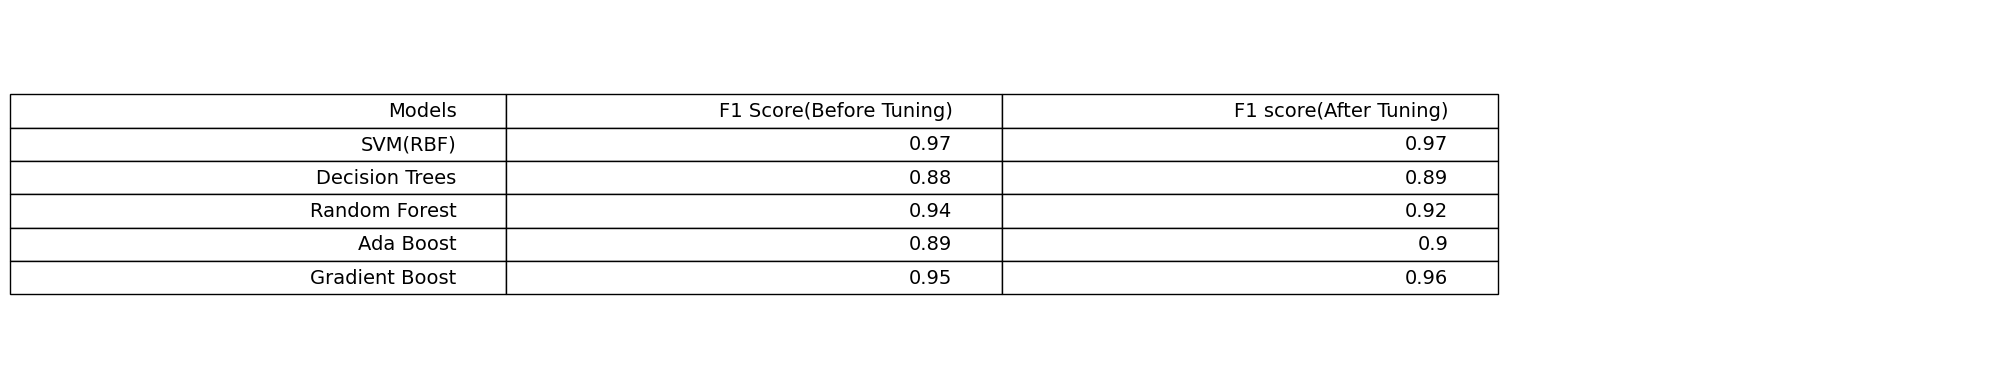

In [ ]:
# Data for the table
y1 = [F1_rbf, F1_dtc, F1_rfc, F1_ab, F1_gb]
f1_score = [F1_rbf_hpt, F1_dtc_hpt, F1_rfc_hpt, F1_ab_hpt, F1_gb_hpt]

data = [
    ["Models", "F1 Score(Before Tuning)","F1 score(After Tuning)"],
    ["SVM(RBF)",round(y1[0],2),round(f1_score[0],2)],
    ["Decision Trees",round(y1[1],2),round(f1_score[1],2)],
    ["Random Forest",round(y1[2],2),round(f1_score[2],2)],
    ["Ada Boost",round(y1[3],2),round(f1_score[3],2)],
    ["Gradient Boost",round(y1[4],2),round(f1_score[4],2)]
]

# Plotting the table
fig, ax = plt.subplots()

# Hide axes
ax.axis('off')

# Hide axes
ax.axis('off')

# Create table
table = ax.table(cellText=data, loc='left')

table.scale(xscale=3, yscale=2)

# Adjust layout
table.auto_set_font_size(False)
table.set_fontsize(14)


plt.show()

**Bar Visualization of F1 scores of models before and after tuning**



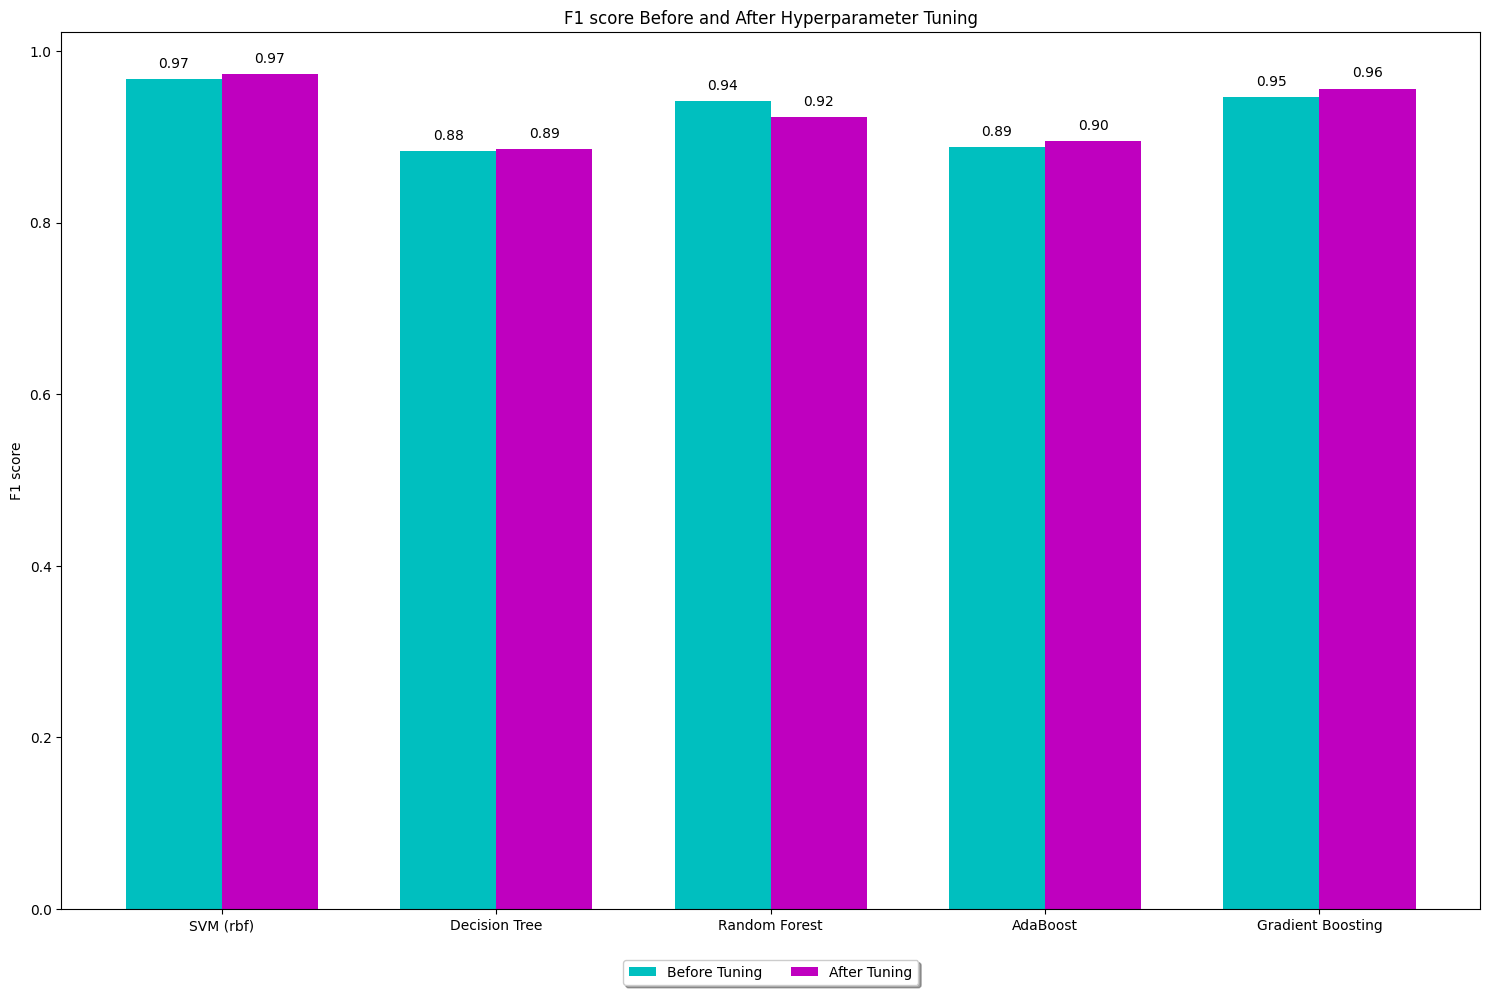

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Model names
models = ["SVM (rbf)", "Decision Tree", "Random Forest", "AdaBoost", "Gradient Boosting"]

# F1 scores before and after hyperparameter tuning
f1_before = [F1_rbf, F1_dtc, F1_rfc, F1_ab, F1_gb]
f1_after = [F1_rbf_hpt, F1_dtc_hpt, F1_rfc_hpt, F1_ab_hpt, F1_gb_hpt]

x = np.arange(len(models))  # Label locations
width = 0.35  # Width of the bars

fig, ax = plt.subplots(figsize=(15, 10))

# Bars for the data before hyperparameter tuning
bars_before = ax.bar(x - width/2, f1_before, width, label='Before Tuning', color='c')

# Bars for the data after hyperparameter tuning
bars_after = ax.bar(x + width/2, f1_after, width, label='After Tuning', color='m')

# Adding labels on top of the bars
for bar in bars_before:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.2f}', ha='center', va='bottom')

for bar in bars_after:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.2f}', ha='center', va='bottom')

# Adding labels, title, and legend
ax.set_ylabel('F1 score')
ax.set_title('F1 score Before and After Hyperparameter Tuning')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), fancybox=True, shadow=True, ncol=5)

# Displaying the plot
plt.tight_layout()
plt.show()


**Feature Reduction**

In [ ]:
#Using PCA to reduce the feactures and fitting it with the best model
from sklearn.decomposition import PCA

pca = PCA(n_components=6)
X_train_pca = pca.fit_transform(X_train_std)
X_test_pca = pca.transform(X_test_std)

rbf_kernel = svm.SVC(kernel='rbf', C=9, gamma=0.1, random_state=42)
rbf_kernel.fit(X_train_pca, y_train)
y_pred = rbf_kernel.predict(X_test_pca)
F1_rbf_pca = f1_score(y_test, y_pred)
F1_rbf_pca

0.8636499850164818

**Feature Selection using the SelectPercentile method**

In [ ]:
Percentile_Selector = SelectPercentile(score_func=f_classif, percentile=50)
X_P50 = Percentile_Selector.fit_transform(X,y)
print(X_P50.shape)
print(Percentile_Selector.get_feature_names_out())
original_feature_names = egs.columns[[int(i[1:]) for i in Percentile_Selector.get_feature_names_out()]]
print(original_feature_names)

(10000, 6)
['x0' 'x1' 'x2' 'x3' 'x9' 'x10']
Index(['tau1', 'tau2', 'tau3', 'tau4', 'g2', 'g3'], dtype='object')


In [ ]:
X_train_std_select = Percentile_Selector.fit_transform(X_train_std,y_train)
X_test_std_select = Percentile_Selector.transform(X_test_std)

rbf_kernel = svm.SVC(kernel='rbf', C=9, gamma=0.1, random_state=42)
rbf_kernel.fit(X_train_std_select, y_train)
y_pred_rbf = rbf_kernel.predict(X_test_std_select)
print(f1_score(y_true = y_test, y_pred = y_pred_rbf))

0.8873152709359606


**Data Visualization using TSNE**

In [ ]:
tsne = TSNE(n_components=2, init='pca', learning_rate='auto',random_state=42)

X_tsne = tsne.fit_transform(X_train)

print(f'tSNE Embedding: Number of samples and attributes: {X_tsne.shape}')

tSNE Embedding: Number of samples and attributes: (7500, 2)


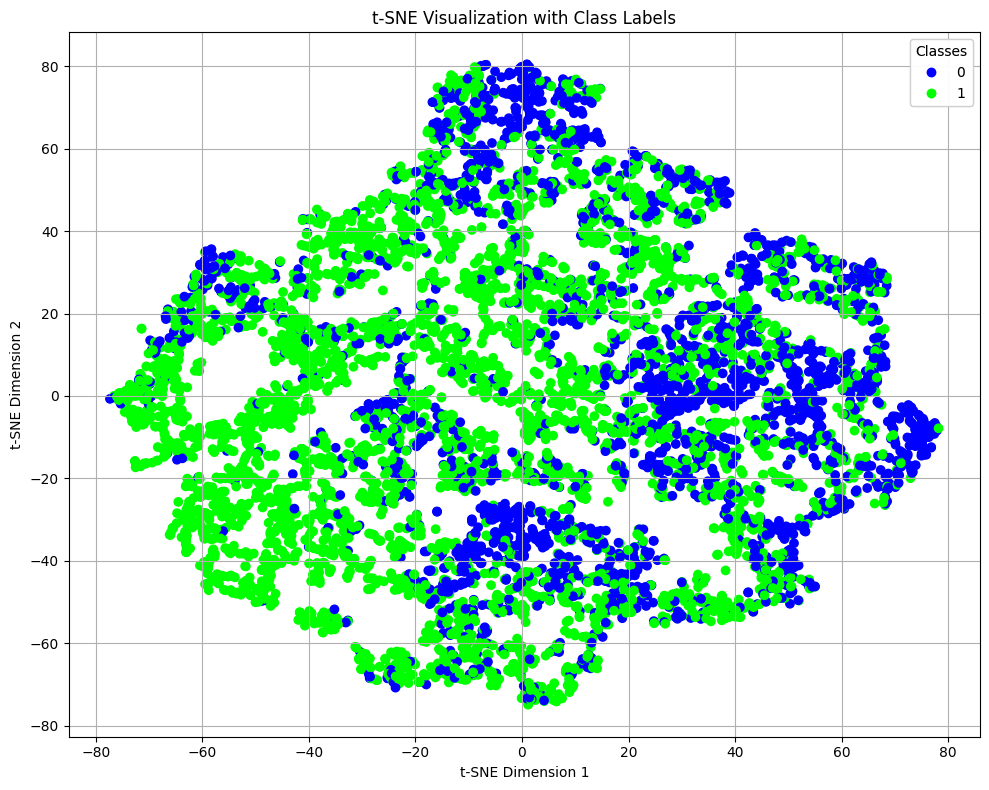

In [ ]:
# Plotting the 2D scatter plot with color based on labels
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_train, cmap=plt.cm.brg,label=y_train)

legend1 = plt.legend(*scatter.legend_elements(), title="Classes")
plt.gca().add_artist(legend1)

plt.title('t-SNE Visualization with Class Labels')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.grid(True)
plt.tight_layout()
plt.show()